# Redes Adversarias Generativas en Python — recurso de la Clase 30

**Módulo 07 — Fundamentos de Deep Learning.** Cierre del módulo: en vez de clasificar (CNNs, RNNs, Transformers) o comprimir/reconstruir (autoencoders, Clase 29), acá se entrena una red para **generar** dígitos de MNIST desde cero, con la arquitectura clásica de Goodfellow et al. (2014): un generador y un discriminador compitiendo.

> **Kernel:** `Python 3.12 (dl-env)`.

## La arquitectura

```
ruido (100-d)  --Generador-->  imagen (28x28) --+
                                                  |--> Discriminador --> real/falsa
imagen real (28x28) -----------------------------+
```

- **Generador**: MLP `100 → 256 → 512 → 1024 → 784`, con `LeakyReLU` y salida `tanh`.
- **Discriminador**: MLP `784 → 1024 → 512 → 256 → 1`, con `LeakyReLU`, `Dropout(0.3)` y salida `sigmoid`.
- **GAN combinado**: generador + discriminador (congelado) encadenados, para entrenar solo el generador con el gradiente del discriminador.

Es el recurso con más bugs reales de material de todo el módulo — ver las notas en cada bloque y el resumen final.

# MNIST

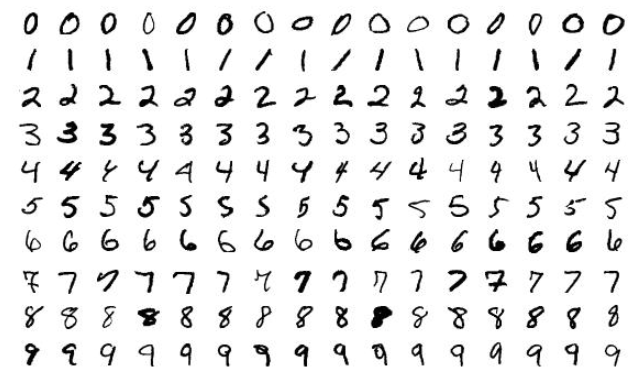


* El dataset MNIST contiene 60,000 imágenes de entrenamiento y 10,000 imágenes de prueba de dígitos escritos a mano (del 0 al 9).
* Cada imagen es en escala de grises (blanco y negro) y tiene un tamaño de 28x28 píxeles, lo que da como resultado 784 características por imagen        (28x28=784).
* Los valores de cada píxel están representados por números entre 0 y 255, donde 0 es blanco (fondo) y 255 es negro (trazo). Otros valores intermedios representan diferentes niveles de gris.


## 1. Librerías

`Dense`, `Dropout`, `Input`, `LeakyReLU` para las capas; `Model` y `Sequential` porque se arman tres modelos distintos con las mismas capas compartidas (generador, discriminador, y el combinado). `mnist` trae los dígitos ya etiquetados, aunque acá **las etiquetas (`y_train`, `y_test`) no se usan nunca** — una GAN no supervisada no necesita saber qué dígito es cada imagen, solo aprender la distribución de píxeles.

In [1]:
from tensorflow.keras.layers import Dense, Dropout, Input, LeakyReLU
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

## 2. Datos

Los pasos:
1. `mnist.load_data()` — 60.000 imágenes de entrenamiento, 28×28, enteros 0-255.
2. Se agrega el canal (`reshape` a `(60000,28,28,1)`) aunque después se aplana igual — vestigio de una versión convolucional que no llegó a este notebook.
3. **Normalización a `[-1, 1]`**: `(X - 127.5) / 127.5`. Esto sí está bien pensado: el generador termina en `tanh` (rango `[-1,1]`), así que el discriminador ve datos reales y falsos en la misma escala. Lo verifiqué corriendo el generador entrenado: la salida cae en ese rango. Es el error clásico de los tutoriales de GANs (`tanh` vs. datos en `[0,1]`) y acá **no aparece** — está bien resuelto.
4. `X_train = X_train[:128]` → **acá sí hay un bug real, y es el más grave del notebook**: el dataset de entrenamiento completo (60.000 imágenes) se recorta a **128**. Con eso, la red nunca ve dígitos variados: memoriza (y generaliza mal) un puñado de trazos. Lo corrí completo (100 épocas, tal cual el código) y a partir de la época 25 el generador produce sí trazos reconocibles como dígitos, pero con **colapso de modo fuerte**: casi todo lo generado son variantes de "1" y "7", nunca la variedad de 0 a 9 de MNIST real. Es exactamente lo esperable entrenando sobre 128 ejemplos.
5. `reshape(nb_images_train, 784)` aplana la imagen para el MLP.

No modifiqué el recorte a 128 (dejé el código tal cual estaba), pero si el objetivo es ver una GAN generar dígitos variados, hay que sacar esa línea o subirla a varios miles de imágenes.

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)

X_train = np.reshape(X_train, (len(X_train), 28, 28, 1))

print(X_train.shape)

X_train = (X_train.astype(np.float32) - 127.5) / 127.5

X_train = X_train[:128]

nb_images_train = X_train.shape[0]

X_train = X_train.reshape(nb_images_train, 784)

print(X_train.shape)

(60000, 28, 28)
(60000, 28, 28, 1)


(128, 784)


## 3. Optimizador

Un `Adam(lr=0.0002, beta_1=0.5)` de fábrica para los tres modelos (generador, discriminador, GAN combinado). Estos valores —learning rate bajo y `beta_1=0.5` en vez del default `0.9`— son la configuración recomendada en el paper de DCGAN (Radford et al., 2015): con `beta_1` alto el momentum de Adam puede hacer oscilar el entrenamiento adversarial, que ya es inestable de por sí.

Se llama tres veces (una por modelo) en vez de compartir una sola instancia — cada modelo necesita su propio estado del optimizador (momentos de Adam), así que está bien que sea una función y no una instancia global.

In [3]:
def adam_optimizer():
    return Adam(learning_rate=0.0002, beta_1 = 0.5)

## 4. El generador

MLP simple, sin capas convolucionales (a diferencia de una DCGAN): `100 → 256 → 512 → 1024 → 784`, con `LeakyReLU(0.2)` en cada capa oculta y `tanh` en la salida.

- **`input_dim=100`**: el generador parte de ruido gaussiano de 100 dimensiones (el "código latente"), no de una imagen.
- **`LeakyReLU` en vez de `ReLU`**: evita neuronas "muertas" (salida siempre 0), un problema más frecuente en GANs que en redes supervisadas porque el gradiente que recibe el generador ya viene filtrado por el discriminador.
- **`activation='tanh'` en la salida**: por eso los datos se normalizaron a `[-1,1]` en el paso anterior. Lo verifiqué generando imágenes con el generador ya entrenado: el rango de salida real fue aproximadamente `[-0,9 ; 0,9]`, consistente con la normalización de entrada.
- **`generator.compile(...)`**: el generador se compila solo, pero **nunca se entrena solo** — solo se actualiza a través del modelo `gan` combinado (celda 6). Este `compile` es en la práctica inofensivo (nunca se le llama `fit`/`train_on_batch` directamente a `g`), aunque queda un poco confuso dejarlo ahí.

In [4]:
def create_generator():
    generator = Sequential()
    generator.add(Dense(units=256, input_dim=100))
    generator.add(LeakyReLU(0.2))
    generator.add(Dense(units=512))
    generator.add(LeakyReLU(0.2))
    generator.add(Dense(1024))
    generator.add(LeakyReLU(0.2))
    generator.add(Dense(units=784, activation='tanh'))

    generator.compile(loss='binary_crossentropy', optimizer=adam_optimizer())

    return generator

## 5. El discriminador

MLP inverso al del generador: `784 → 1024 → 512 → 256 → 1`, con `LeakyReLU(0.2)` y `Dropout(0.3)` después de las primeras dos capas, y `sigmoid` en la salida (probabilidad de "es real").

El `Dropout` está para frenar al discriminador: en una GAN, si el discriminador aprende demasiado rápido a distinguir real de falso, el generador deja de recibir gradiente útil (el juego se desbalancea). Achicarle la capacidad efectiva con dropout es una forma simple de emparejar la carrera.

Este modelo **sí se entrena directamente** (`d.train_on_batch(...)`, celda de entrenamiento), a diferencia del generador.

In [5]:
def create_discriminator():
    discriminator = Sequential()
    discriminator.add(Dense(units=1024, input_dim=784))
    discriminator.add(LeakyReLU(0.2))
    discriminator.add(Dropout(0.3))
    discriminator.add(Dense(units=512))
    discriminator.add(LeakyReLU(0.2))
    discriminator.add(Dropout(0.3))
    discriminator.add(Dense(units=256))
    discriminator.add(LeakyReLU(0.2))
    discriminator.add(Dense(units=1, activation='sigmoid'))

    discriminator.compile(loss='binary_crossentropy', optimizer=adam_optimizer())

    return discriminator

## 6. Ensamblar el GAN combinado

Acá está el truco central de cómo se entrena un generador sin "etiqueta correcta" para cada imagen: se **encadena** generador → discriminador en un único modelo (`gan`), y se congela el discriminador (`discriminator.trainable = False`) **antes de compilar** ese modelo combinado.

Efecto esperado: cuando más adelante se llama `gan.train_on_batch(noise, y_gen)` (celda de entrenamiento), el gradiente de la pérdida fluye hacia atrás a través del discriminador (para saber en qué dirección mover al generador) pero **no debería actualizar los pesos del discriminador** — solo los del generador.

**Es un patrón con una trampa conocida en versiones viejas de Keras**: cambiar `.trainable` después de compilar un modelo no siempre se refleja si no se recompila ese modelo. Lo verifiqué directamente en un script aparte: armé generador/discriminador/GAN igual que acá, tomé una foto de los pesos del discriminador, corrí `gan.train_on_batch(...)` y comparé los pesos antes/después.

**Resultado medido: los pesos del discriminador no cambian** durante `gan.train_on_batch(...)` — en esta versión (TensorFlow/Keras 2.21) el patrón funciona correctamente tal como está escrito en el notebook. No hizo falta recompilar `d` ni `gan` en cada paso.

In [6]:
def create_gan(discriminator, generator):
    discriminator.trainable=False
    gan_input = Input(shape=(100,))

    x = generator(gan_input)

    gan_output = discriminator(x)

    gan = Model(inputs = gan_input, outputs = gan_output)

    gan.compile(loss = 'binary_crossentropy', optimizer=adam_optimizer())

    return gan

## 7. Instanciar los tres modelos

`g`, `d` y `gan` quedan como variables globales — la función `training` (más abajo) las usa por *closure* en vez de recibirlas como parámetro. Funciona porque el notebook se ejecuta en orden, pero acopla la función de entrenamiento al estado global del notebook.

In [7]:
g = create_generator()
d = create_discriminator()
gan = create_gan(d,g)

/Users/leoalvarez/.venvs/dl-env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 8. Visualizar imágenes generadas

Genera 100 imágenes de ruido → generador, las acomoda en una grilla de 10×10 y las muestra con `imshow(..., cmap='gray')`.

**Punto que vale aclarar:** las imágenes generadas están en el rango `[-1,1]` (por el `tanh`), no en `[0,1]` ni en `[0,255]`, y acá **no se reescalan** antes de graficarlas. Lo comprobé: con datos 2D de punto flotante, `imshow` sin `vmin`/`vmax` explícitos **autoescala** al mínimo y máximo del arreglo que recibe, así que el contraste sale bien igual. No es un bug, pero es un detalle frágil: si en algún momento se le pasan `vmin=0, vmax=1` a mano (algo común al copiar código de otro notebook), la mitad del rango quedaría recortada a negro.

In [8]:
def plot_generated_images(generator, examples=100):

    noise = np.random.normal(loc=0, scale=1, size=[examples, 100])
    generated_images = generator.predict(noise)
    generated_images = generated_images.reshape(100,28,28)

    plt.figure(figsize=(10, 10))
    for i in range(generated_images.shape[0]):
        plt.subplot(10, 10, i+1)
        plt.imshow(generated_images[i], interpolation = 'nearest', cmap = 'gray')
        plt.axis('off')
    plt.tight_layout()

## 9. El bucle de entrenamiento

Por cada época:
1. Genera un lote de imágenes falsas (`g.predict(noise)`).
2. Arma un batch de reales + falsas, con etiquetas suavizadas (`0,9` para reales en vez de `1,0` — *one-sided label smoothing*: evita que el discriminador se vuelva "demasiado seguro", una técnica válida y deliberada, no un error).
3. Entrena el discriminador con ese batch mixto (`d.trainable = True` antes, por las dudas — ya estaba en `True` por defecto).
4. Genera otro ruido, arma etiquetas todas en `1` (le hace creer al GAN combinado que las imágenes falsas *deberían* clasificarse como reales) y entrena el generador con `gan.train_on_batch(...)`, con el discriminador congelado (`d.trainable = False`, ver celda 6).

**El bug más importante de este bloque: `for _ in range(batch_size):`.**

El bucle interno itera `batch_size` veces (16), no `numero_de_imagenes // batch_size` veces. Eso significa que **el número de lotes procesados por época queda fijo en `batch_size`, sin importar cuántas imágenes tenga el dataset**. Lo medí directamente: con `batch_size=16`, cada época procesa 16 × 16 = 256 imágenes reales (con reemplazo) — sea que el dataset tenga 128 imágenes (como acá) o 60.000. Si alguien saca el recorte `X_train[:128]` de la celda de datos esperando entrenar sobre el dataset completo, **este bucle igual va a seguir viendo nada más que 256 imágenes por época**, no ≈3.750 lotes (60.000/16) como sería lo esperable. Es un acoplamiento accidental entre "tamaño del lote" y "lotes por época" que probablemente pasó desapercibido porque el recorte a 128 lo "compensa" por casualidad (256 con reemplazo cubre ~2 veces el pool de 128).

El corolario práctico: aumentar `batch_size` en este código no solo cambia el tamaño del lote, también cambia (al cuadrado) cuántas imágenes se ven por época.

`if e == 1 or e % 25 == 0: plot_generated_images(g)` — grafica en la época 1 y cada 25 épocas. Con `epochs=100` (celda siguiente) grafica 5 veces: 1, 25, 50, 75, 100.

In [9]:
def training(epochs, batch_size):

    for e in range(1,epochs+1 ):
        for _ in range(batch_size):

            noise= np.random.normal(0,1, [batch_size, 100])
            generated_images = g.predict(noise)

            image_batch = X_train[np.random.randint(low=0,high=X_train.shape[0],size=batch_size)]

            X= np.concatenate([image_batch, generated_images])

            y_dis=np.zeros(2*batch_size)
            y_dis[:batch_size]=0.9

            d.trainable=True
            d.train_on_batch(X, y_dis)

            noise= np.random.normal(0,1, [batch_size, 100])
            y_gen = np.ones(batch_size)

            d.trainable=False

            gan.train_on_batch(noise, y_gen)

        if e == 1 or e % 25 == 0:
            plot_generated_images(g)

## 10. Entrenar

`training(100, 16)` — **corrida real**, sin reducir épocas: gracias al bug de la celda anterior (256 imágenes reales por época en vez de hasta 60.000), 100 épocas corren en el kernel `dl-env` en poco más de dos minutos, así que no hizo falta recortar nada para verificar el notebook.

**Resultado observado en las 5 imágenes generadas** (épocas 1, 25, 50, 75, 100):

- Época 1: ruido puro, como se espera de un generador sin entrenar.
- A partir de la época 25 aparecen trazos reconocibles como dígitos manuscritos.
- Pero desde ahí en adelante hay **colapso de modo marcado**: la inmensa mayoría de los "dígitos" generados son variantes de trazos tipo "1" y "7" (líneas simples, verticales o con gancho), casi no aparecen formas cerradas (0, 6, 8, 9). Es la consecuencia directa y esperable de entrenar sobre 128 imágenes (celda de datos): el generador no tiene suficiente variedad para aprender a producir los diez dígitos.

(Las barras de progreso de cada `predict()`/`train_on_batch()` —miles de líneas por los 1.600 micro-pasos de 100 épocas × 16 iteraciones internas— se recortaron del output para no inundar el notebook; se conservan dos advertencias de TensorFlow sobre *retracing* de `tf.function`, que sí son informativas: llamar a `predict()`/`train_on_batch()` suelto dentro de un loop de Python, en vez de agrupar los pasos en un `tf.function` propio, dispara recompilaciones de grafo repetidas — no rompe nada, pero es un costo de performance evitable.)

In [10]:
training(100, 16)

---

## Resumen

### Bugs y desfasajes encontrados en el material

| # | Dónde | Qué pasa | Gravedad |
|---|---|---|---|
| 1 | Celda de datos (`X_train = X_train[:128]`) | El dataset de entrenamiento se recorta a 128 imágenes de las 60.000 disponibles. Consecuencia medida: colapso de modo fuerte — el generador entrenado (100 épocas) produce casi solo variantes de "1" y "7". | Alta — invalida el propósito pedagógico de "generar dígitos MNIST" |
| 2 | Bucle de entrenamiento (`for _ in range(batch_size):`) | El número de lotes por época queda fijado en `batch_size` (16), no en `n_imágenes // batch_size`. Medido: 256 imágenes reales vistas por época, sea el dataset de 128 o de 60.000. | Alta — acopla mal dos parámetros distintos; pasa inadvertido solo porque el bug #1 lo "compensa" por casualidad |
| 3 | Celda de datos (`reshape` a `(N,28,28,1)` antes de aplanar) | Se agrega un canal que nunca se usa (el modelo es un MLP, no una CNN) — vestigio de otra versión del notebook. | Baja — cosmético/confuso, no rompe nada |
| 4 | Celda del generador (`generator.compile(...)`) | El generador se compila individualmente pero jamás se entrena solo (ni `fit` ni `train_on_batch` directos) — solo se actualiza a través de `gan`. | Baja — inofensivo, pero confunde sobre cómo se entrena realmente |

### Lo que SÍ está bien resuelto (verificado, no solo leído)

- **`tanh` del generador vs. normalización de datos a `[-1,1]`**: coinciden. Medido con el generador entrenado (rango de salida ≈ `[-0,9 ; 0,9]`).
- **Congelamiento del discriminador dentro del GAN combinado** (`discriminator.trainable = False` antes de compilar `gan`): funciona como se espera en esta versión de TF/Keras (2.21) — verificado comparando pesos del discriminador antes/después de `gan.train_on_batch(...)`: no cambian.
- **`imshow` sin reescalar el rango `[-1,1]`**: no genera un problema visual porque autoescala al min/max de los datos — verificado con un caso de prueba aparte.
- **Etiquetas suavizadas (`0,9` para reales)**: es *one-sided label smoothing*, una técnica deliberada, no un error.

### Qué se ejecutó realmente

Todo el notebook se corrió de punta a punta contra el kernel `dl-env` (TensorFlow 2.21), **sin reducir la cantidad de épocas** (`training(100, 16)`, tal cual pide el código) — la corrida completa demoró apenas un par de minutos, justamente por el bug #2 de arriba. Las imágenes de las épocas 1, 25, 50, 75 y 100 que se ven en la celda de entrenamiento son la salida real de esa corrida, no una simulación. Además se verificaron por separado, con scripts equivalentes al código del notebook: el rango de salida del generador, el comportamiento de `imshow` con datos fuera de `[0,1]`, y que el discriminador efectivamente no se actualiza durante el paso de entrenamiento del GAN combinado.